In [4]:
pip install google-cloud-bigquery

In [5]:
from google.colab import auth
auth.authenticate_user()

In [6]:
from google.cloud import bigquery

client = bigquery.Client(project='nyc-taxi-analysis-507515')

In [7]:
import pandas as pd
Query = ''' SELECT *
 FROM `nyc-taxi-analysis-507515.Nyc_taxi_trips.cleaned_taxi_data`
 ORDER BY RAND()
  limit 100000'''

df = client.query(Query).to_dataframe()

In [8]:
df

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,...,airport_fee,total_amount,pickup_location_id,dropoff_location_id,data_file_year,data_file_month,trip_duration_minutes,year,day,month
0,2,2021-04-24 20:22:34+00:00,2021-04-24 20:32:24+00:00,2,1.000000000,1.0,N,1,8.000000000,1.000000000,...,0E-9,14.000000000,170,68,2021,4,9,2021,Saturday,April
1,2,2021-03-27 15:10:36+00:00,2021-03-27 15:23:06+00:00,1,1.000000000,1.0,N,2,9.000000000,0E-9,...,None,12.000000000,264,264,2021,3,12,2021,Saturday,March
2,1,2021-09-26 03:55:57+00:00,2021-09-26 04:26:40+00:00,2,17.000000000,1.0,N,1,48.000000000,3.000000000,...,0E-9,51.000000000,125,18,2021,9,30,2021,Sunday,September
3,2,2021-11-01 17:52:27+00:00,2021-11-01 18:01:19+00:00,1,1.000000000,1.0,N,1,8.000000000,1.000000000,...,0E-9,14.000000000,230,43,2021,11,8,2021,Monday,November
4,2,2021-10-04 21:53:02+00:00,2021-10-04 22:05:24+00:00,1,2.000000000,1.0,N,1,11.000000000,1.000000000,...,0E-9,17.000000000,142,263,2021,10,12,2021,Monday,October
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2,2021-11-22 20:37:05+00:00,2021-11-22 20:48:24+00:00,1,2.000000000,1.0,N,1,9.000000000,1.000000000,...,0E-9,15.000000000,100,229,2021,11,11,2021,Monday,November
99996,2,2021-07-17 15:43:38+00:00,2021-07-17 16:10:47+00:00,1,6.000000000,1.0,N,2,21.000000000,0E-9,...,0E-9,24.000000000,231,80,2021,7,27,2021,Saturday,July
99997,2,2021-12-24 13:27:49+00:00,2021-12-24 13:33:20+00:00,1,1.000000000,1.0,N,2,6.000000000,0E-9,...,0E-9,7.000000000,166,166,2021,12,5,2021,Friday,December
99998,2,2021-04-18 14:23:59+00:00,2021-04-18 14:46:43+00:00,1,5.000000000,1.0,N,1,20.000000000,0E-9,...,0E-9,27.000000000,164,179,2021,4,22,2021,Sunday,April


In [9]:
df = df.replace(0E-9,0)

/tmp/ipykernel_488/3813967916.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(0E-9,0)


In [10]:
df['trip_distance'] = df['trip_distance'].astype(float)
df['fare_amount'] = df['fare_amount'].astype(float)
df['mta_tax'] = df['mta_tax'].astype(float)
df['tip_amount'] = df['tip_amount'].astype(float)
df['total_amount'] = df['total_amount'].astype(float)
df['extra'] = df['extra'].astype(float)
df['tolls_amount'] = df['tolls_amount'].astype(float)
df['airport_fee'] = df['airport_fee'].astype(float)

In [11]:
df['booking_hour']=df['pickup_datetime'].dt.hour

In [12]:
df

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,...,total_amount,pickup_location_id,dropoff_location_id,data_file_year,data_file_month,trip_duration_minutes,year,day,month,booking_hour
0,2,2021-04-24 20:22:34+00:00,2021-04-24 20:32:24+00:00,2,1.0,1.0,N,1,8.0,1.0,...,14.0,170,68,2021,4,9,2021,Saturday,April,20
1,2,2021-03-27 15:10:36+00:00,2021-03-27 15:23:06+00:00,1,1.0,1.0,N,2,9.0,0.0,...,12.0,264,264,2021,3,12,2021,Saturday,March,15
2,1,2021-09-26 03:55:57+00:00,2021-09-26 04:26:40+00:00,2,17.0,1.0,N,1,48.0,3.0,...,51.0,125,18,2021,9,30,2021,Sunday,September,3
3,2,2021-11-01 17:52:27+00:00,2021-11-01 18:01:19+00:00,1,1.0,1.0,N,1,8.0,1.0,...,14.0,230,43,2021,11,8,2021,Monday,November,17
4,2,2021-10-04 21:53:02+00:00,2021-10-04 22:05:24+00:00,1,2.0,1.0,N,1,11.0,1.0,...,17.0,142,263,2021,10,12,2021,Monday,October,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2,2021-11-22 20:37:05+00:00,2021-11-22 20:48:24+00:00,1,2.0,1.0,N,1,9.0,1.0,...,15.0,100,229,2021,11,11,2021,Monday,November,20
99996,2,2021-07-17 15:43:38+00:00,2021-07-17 16:10:47+00:00,1,6.0,1.0,N,2,21.0,0.0,...,24.0,231,80,2021,7,27,2021,Saturday,July,15
99997,2,2021-12-24 13:27:49+00:00,2021-12-24 13:33:20+00:00,1,1.0,1.0,N,2,6.0,0.0,...,7.0,166,166,2021,12,5,2021,Friday,December,13
99998,2,2021-04-18 14:23:59+00:00,2021-04-18 14:46:43+00:00,1,5.0,1.0,N,1,20.0,0.0,...,27.0,164,179,2021,4,22,2021,Sunday,April,14


In [13]:
df.shape

(100000, 25)

In [14]:
df.shape[0]

100000

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [16]:
hourly_trips =df.groupby('booking_hour').size()

#Trips by hour

Text(0.5, 1.0, 'Trips by Hour')

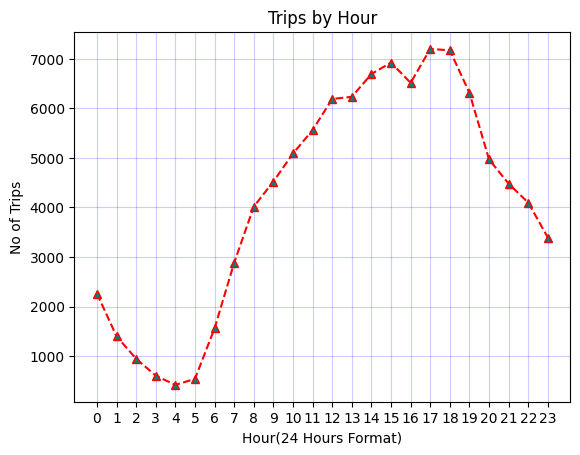

In [17]:
plt.plot(hourly_trips.index,hourly_trips.values,color='red',marker='^',markerfacecolor='teal',linestyle='--')
plt.xticks(hourly_trips.index)
plt.grid(alpha=0.2,color = 'blue')
plt.xlabel('Hour(24 Hours Format)')
plt.ylabel('No of Trips')
plt.title('Trips by Hour')

#Insight:
#we can see that around odd hours the demand is extremely low , we can see  from mid 00:00 hours till 04:00 hours the demand dropped significantly.
#whereas after  04:00 to 05:00 the  demand rises to some extent . after which we can see there  is a huge spike in demand suggests that because probablhy
#office shifts this may happen. and it gradually grows over time  till 14:00 hours. it could be interpreted as the time between 14:00 to 16:00
#most cab drivers can  have their lunch. that is why there might a stagnation  after that we can again see a spike at 17:00 hours which is the hour with most demand
# we can see interpret that office shift are begining to get over (as most shifts are 9 - 5) this ccould effect the demand to rise  .After 17:00 hours ,it peaked at 18:00
#then we can see a gradual drop in demands suggesting wrapping of the day .( i took a generalised idea of the local office commuters as the represent most of the
#city's population,most business owners and staffs may follow the same schedules , tourists may representation may be significantly low  )

#Trips by Month

In [18]:
months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']

df['month'] = pd.Categorical(df['month'], categories= months, ordered=True)

trips_by_month = df.groupby('month',observed=True).size()

Text(0, 0.5, 'No of trips')

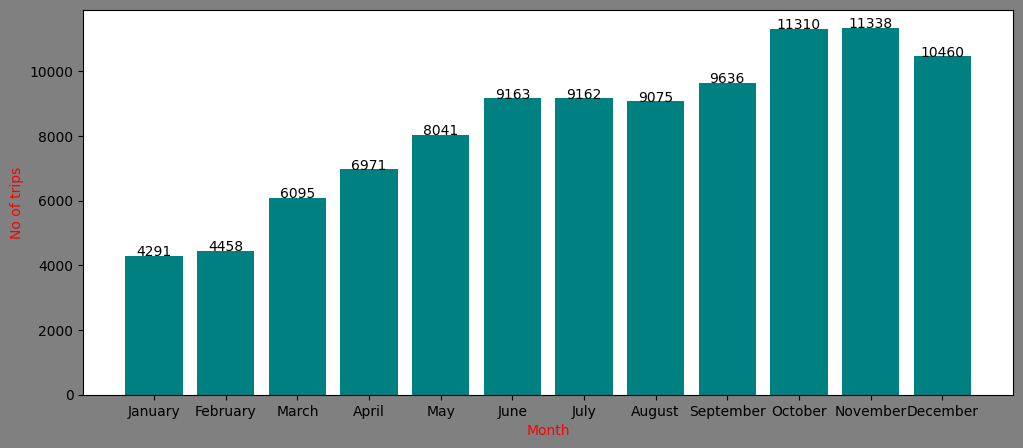

In [19]:
plt.figure(figsize=(12,5),facecolor='Grey')
bars = plt.bar(trips_by_month.index,trips_by_month.values,color='Teal')
for bar in bars:
  plt.text(bar.get_x()+(bar.get_width())/2,bar.get_height(),f'{bar.get_height()}',ha = 'center')
plt.xlabel('Month',color='Red')
plt.ylabel('No of trips',color='Red')
#Inights:
#we can see that  january and february  have the lowest  demand the year  however from march till june there is some steady growth ,june , july ,august and september have similar
#number of trips whereas  we can see october , november and december remains the most demansing months , this could be because of the holiday season
#also new york having a much pleasent weather

#Average Fare by Hour

In [20]:
fare_by_hour = df.groupby('booking_hour')['fare_amount'].mean()

Text(0.5, 0, 'Booking Hour')

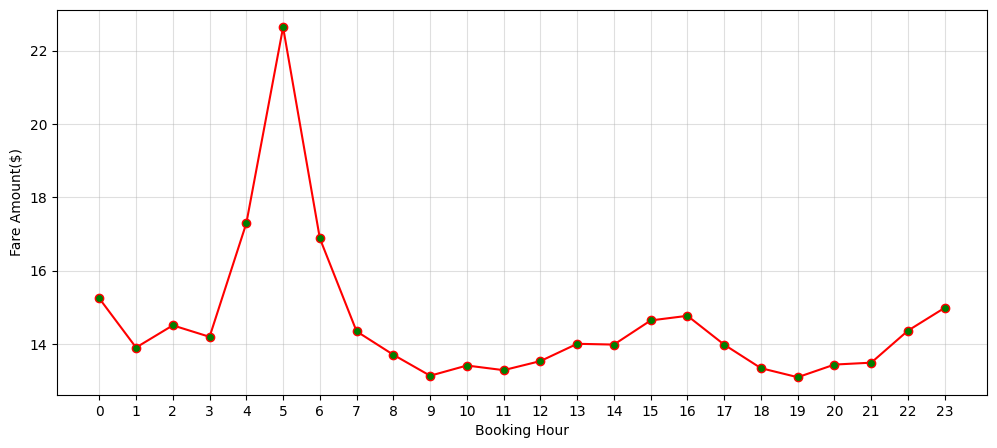

In [21]:
plt.figure(figsize=(12,5))
plt.plot(fare_by_hour.index,fare_by_hour.values,marker='o',markerfacecolor='green',color='red')
plt.grid(alpha=0.4)
plt.xticks(fare_by_hour.index)
plt.ylabel('Fare Amount($)')
plt.xlabel('Booking Hour')

#Insights
#The average fare amount changes noticeably throughout the day based on trip distance and commuting habits.
#Fares surge early in the morning between 4 AM and 6 AM, hitting a peak of over $21 at 5 AM due to long-distance journeys
#like airport trips. Fares then drop and stay low between 8 AM and 1 PM at around $13 to $13.50, reflecting shorter local rides during regular business hours.
# A smaller bump appears during the evening rush hour around 3 PM to 4 PM at $14.60 before steadily rising again late at night.


#Trip Duration Distribution

In [22]:
duration_trips =df.groupby('trip_duration_minutes').size()

Text(0.5, 1.0, 'Trip Duration distribution')

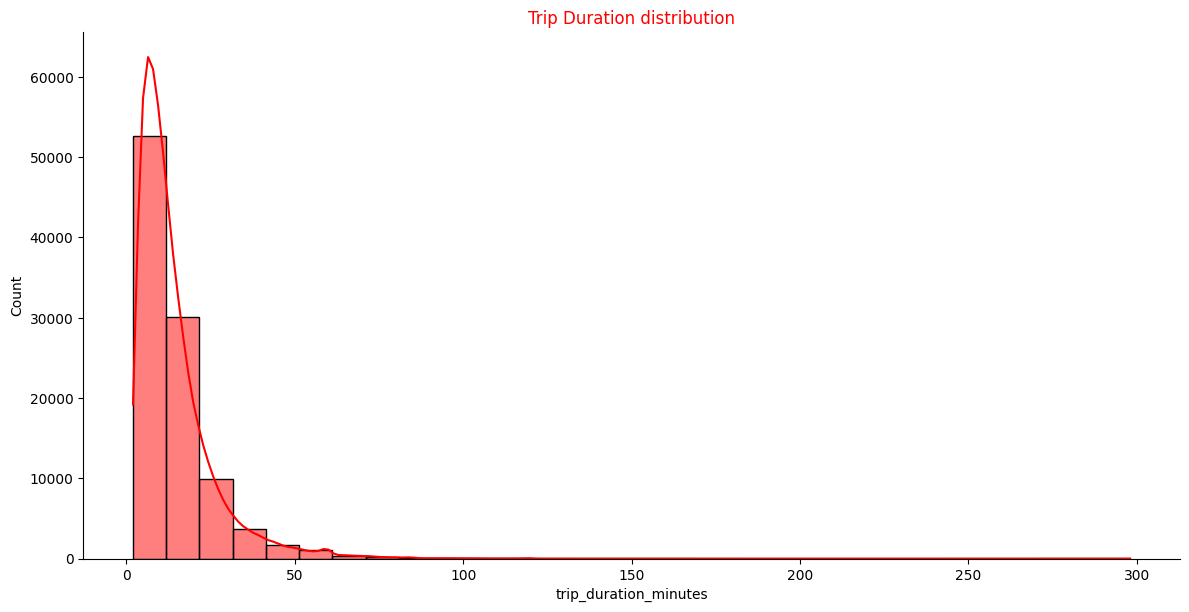

In [23]:

sns.displot(x=df['trip_duration_minutes'],kde=True,binwidth=10,color ='red',height=6,aspect=2)
plt.title('Trip Duration distribution',color='red')
# we can see clearly that  the  most observations we can find is between 1 - 10 mins,10-20 mins have signficatnly low observations and it gradually decreases with increase in
#in duration

# Trip Distance vs Trip Duration

<Axes: xlabel='trip_distance', ylabel='trip_duration_minutes'>

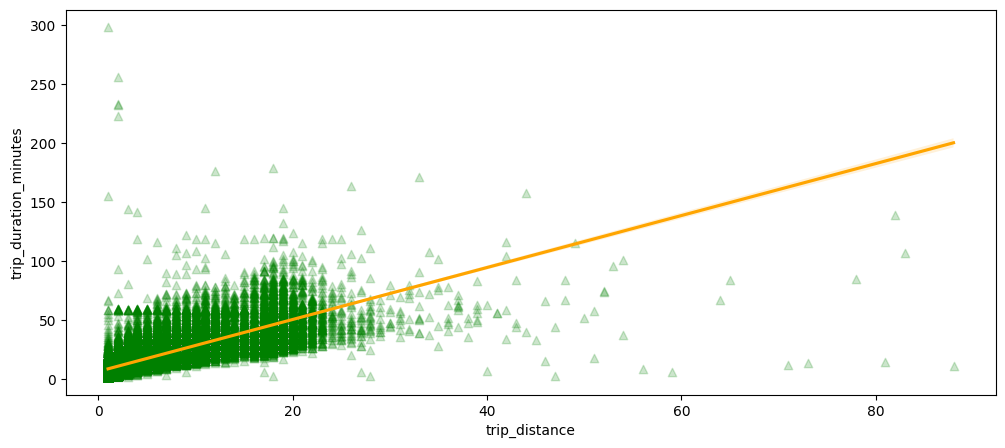

In [24]:

plt.figure(figsize=(12,5))
sns.regplot(x =df['trip_distance'],y=df['trip_duration_minutes'],color= 'red',marker='^',scatter_kws = {'color':'green','alpha':0.2},line_kws={'color':'orange'})

In [25]:
df[['trip_distance','trip_duration_minutes']].corr()
#the corelation is 0.77 and we can see that using scatterplot and regression line as well that there is a strong positive correlation
#it is completely understandable that  with increase in distance the time also increases

,trip_distance,trip_duration_minutes
trip_distance,1.000000,0.777853
trip_duration_minutes,0.777853,1.000000


#Trip Distance vs Fare

<Axes: xlabel='trip_distance', ylabel='fare_amount'>

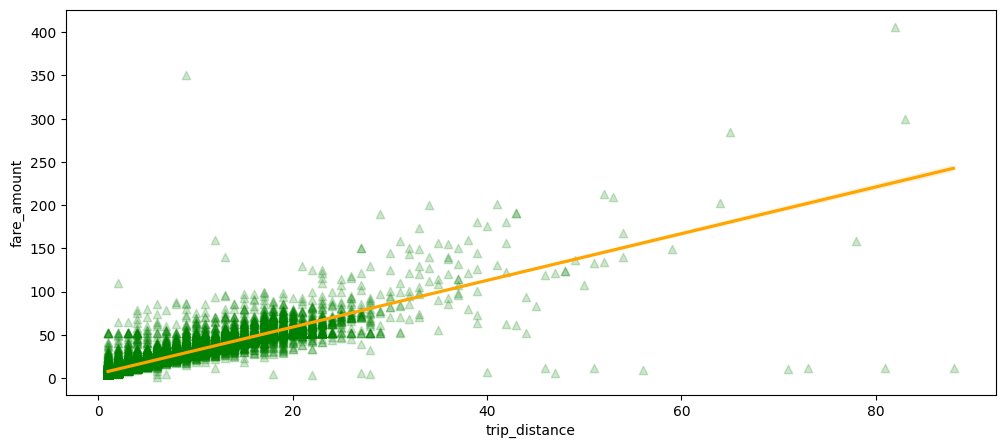

In [26]:

plt.figure(figsize=(12,5))
sns.regplot(x =df['trip_distance'],y=df['fare_amount'],color= 'red',marker='^',scatter_kws = {'color':'green','alpha':0.2},line_kws={'color':'orange'})

In [27]:
df[['trip_distance','fare_amount']].corr()
#We can observe a strong positive correlation with trip distancce and fare_amount

,trip_distance,fare_amount
trip_distance,1.000000,0.935687
fare_amount,0.935687,1.000000


In [28]:
df[['trip_distance','fare_amount']].describe()

,trip_distance,fare_amount
count,100000.000000,100000.000000
mean,3.388440,13.985410
std,4.134224,11.938106
min,1.000000,1.000000
25%,1.000000,7.000000
50%,2.000000,10.000000
75%,3.000000,15.000000
max,88.000000,406.000000


In [29]:
#Insight:
#During Pandas analysis, a strong relationship between trip distance and fare amount was observed, which showed a significant discrepancy
# compared with the SQL correlation result (0.93 in Pandas vs 0.064 in SQL). This difference prompted further investigation of the data and
#revealed several extreme fare outliers. Six records with `fare_amount > 600` were identified and excluded from the correlation analysis.
# After removing these extreme values, the SQL correlation increased from 0.064 to 0.935, confirming a strong positive relationship between trip distance
# and fare amount.


#Payment Type Distribution

In [30]:
df['payment_type']=df['payment_type'].astype(int)

In [31]:
def payment_map(value):
  if value == 0:
    return 'Un-documented'
  elif value == 1:
    return 'Credit card'
  elif value == 2:
    return 'Cash'
  elif value == 3:
    return 'No-Charge'
  elif value == 4:
    return 'Dispute'
  elif value == 5:
    return 'Unknown'
  elif  value == 6:
    return 'Voided trip'


df['payment_category']=df['payment_type'].apply(lambda x : payment_map(x) )

In [32]:
df.groupby(df['payment_category']).size()

,0
payment_category,
Cash,21065
Credit card,73645
Dispute,119
No-Charge,299
Un-documented,4872


In [33]:
paymentype = df.groupby(df['payment_category']).size()

Text(0.5, 0, 'No of transactions')

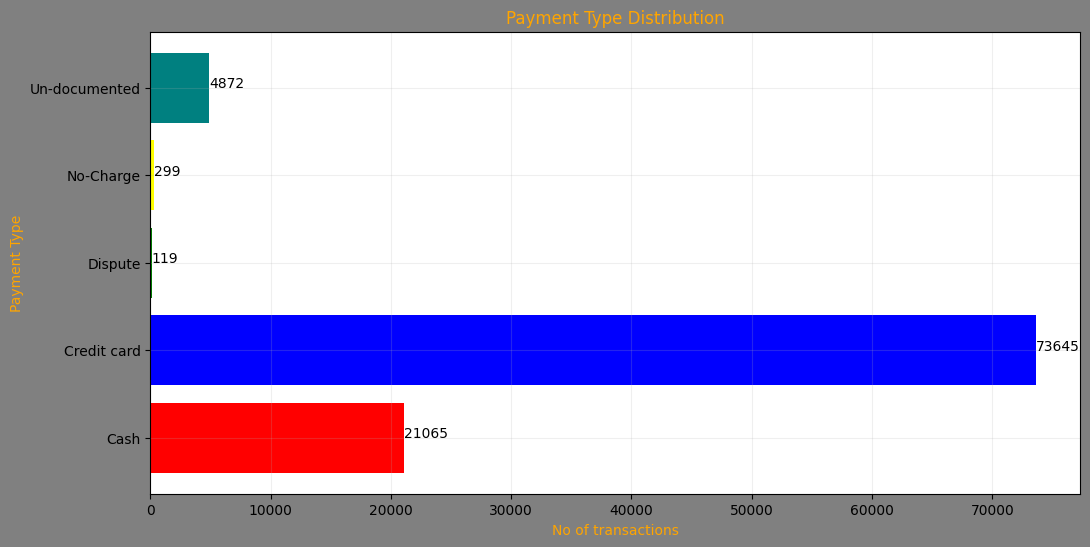

In [34]:
plt.figure(figsize=(12,6),facecolor='grey')
barhs = plt.barh(paymentype.index,paymentype.values,color = ['red','blue','green','yellow','teal'])

for barh in barhs:
  plt.text(barh.get_width()+0.4,barh.get_y()+barh.get_height()/2,f'{barh.get_width()}')
plt.grid(alpha=0.2)

plt.title('Payment Type Distribution',color='orange')
plt.ylabel('Payment Type',color='orange')
plt.xlabel('No of transactions',color='orange')

#Insights:
#We can clearly see the Biquery and pandas visualisation shows the same story ,where most of the transactions were done using credit card , followed by cash .
#There are some 4898 transactions done using un-documneted methods .
#NOTE: THERE ARE THE VALUES REPRESENT ONLY 100,000 rows out of 28.1 million cleaned rows .original was count was 30.9 million rows


#Passenger Count Distribution



/tmp/ipykernel_488/1777636658.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['passenger_count'],palette='icefire')


(array([    0., 10000., 20000., 30000., 40000., 50000., 60000., 70000.,
        80000.]),
 [Text(0, 0.0, '0'),
  Text(0, 10000.0, '10000'),
  Text(0, 20000.0, '20000'),
  Text(0, 30000.0, '30000'),
  Text(0, 40000.0, '40000'),
  Text(0, 50000.0, '50000'),
  Text(0, 60000.0, '60000'),
  Text(0, 70000.0, '70000'),
  Text(0, 80000.0, '80000')])

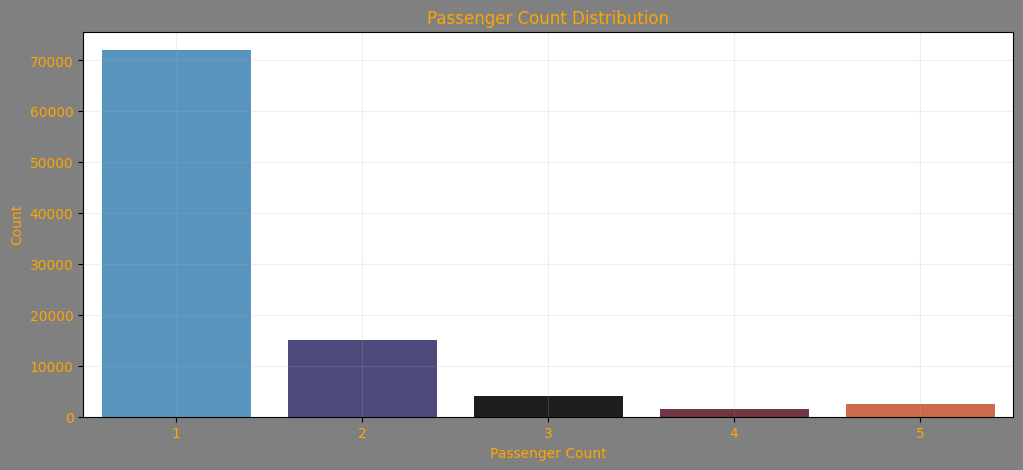

In [35]:
plt.figure(figsize=(12,5),facecolor='Grey')
sns.countplot(x=df['passenger_count'],palette='icefire')
plt.grid(alpha=0.2)
plt.ylabel('Count',color='orange')
plt.xlabel('Passenger Count',color='orange')
plt.title('Passenger Count Distribution',color='orange')
plt.xticks(color='orange')

plt.yticks(color='orange')

In [36]:
#Insights:
#Single-passenger rides dominate the distribution by a mile, accounting for over 70,000 out of the 100,000-row visualization sample.
#Two-passenger trips drop off sharply to around 15,000, while group rides with three or more passengers make up only a tiny fraction of the total volume.
#This sample reflects the broader 28.1 million row dataset, showing that NYC taxis are primarily used for individual solo commuting rather than group travel.

#Average Fare by Trip Duration Category

In [37]:
def duration_map(value):
  if value < 10:
    return 'Short Trip'
  elif value >=10 and value <=30:
    return 'Medium Trip'
  else:
    return 'Long trip'

# I have kept the mapping methodology for trip duration category same as what i have applied on SQL

df['duration_category']=df['trip_duration_minutes'].apply(lambda x : duration_map(x))

In [38]:
fare_duration = df.groupby(df['duration_category'])['fare_amount'].mean()

Text(0, 0.5, 'Average Fare Amount')

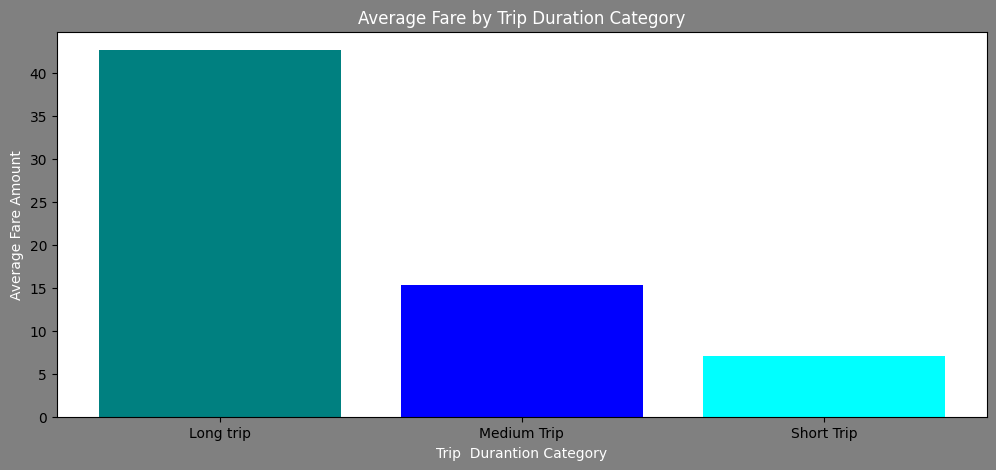

In [39]:
plt.figure(figsize=(12,5),facecolor='grey')
plt.bar(fare_duration.index,fare_duration.values,color=['teal','blue','cyan'])
plt.title('Average Fare by Trip Duration Category',color='white')
plt.xlabel('Trip  Durantion Category',color='white')
plt.ylabel('Average Fare Amount',color ='white')

#Heatmap — Hour × Day of Week

In [40]:
df

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,...,dropoff_location_id,data_file_year,data_file_month,trip_duration_minutes,year,day,month,booking_hour,payment_category,duration_category
0,2,2021-04-24 20:22:34+00:00,2021-04-24 20:32:24+00:00,2,1.0,1.0,N,1,8.0,1.0,...,68,2021,4,9,2021,Saturday,April,20,Credit card,Short Trip
1,2,2021-03-27 15:10:36+00:00,2021-03-27 15:23:06+00:00,1,1.0,1.0,N,2,9.0,0.0,...,264,2021,3,12,2021,Saturday,March,15,Cash,Medium Trip
2,1,2021-09-26 03:55:57+00:00,2021-09-26 04:26:40+00:00,2,17.0,1.0,N,1,48.0,3.0,...,18,2021,9,30,2021,Sunday,September,3,Credit card,Medium Trip
3,2,2021-11-01 17:52:27+00:00,2021-11-01 18:01:19+00:00,1,1.0,1.0,N,1,8.0,1.0,...,43,2021,11,8,2021,Monday,November,17,Credit card,Short Trip
4,2,2021-10-04 21:53:02+00:00,2021-10-04 22:05:24+00:00,1,2.0,1.0,N,1,11.0,1.0,...,263,2021,10,12,2021,Monday,October,21,Credit card,Medium Trip
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2,2021-11-22 20:37:05+00:00,2021-11-22 20:48:24+00:00,1,2.0,1.0,N,1,9.0,1.0,...,229,2021,11,11,2021,Monday,November,20,Credit card,Medium Trip
99996,2,2021-07-17 15:43:38+00:00,2021-07-17 16:10:47+00:00,1,6.0,1.0,N,2,21.0,0.0,...,80,2021,7,27,2021,Saturday,July,15,Cash,Medium Trip
99997,2,2021-12-24 13:27:49+00:00,2021-12-24 13:33:20+00:00,1,1.0,1.0,N,2,6.0,0.0,...,166,2021,12,5,2021,Friday,December,13,Cash,Short Trip
99998,2,2021-04-18 14:23:59+00:00,2021-04-18 14:46:43+00:00,1,5.0,1.0,N,1,20.0,0.0,...,179,2021,4,22,2021,Sunday,April,14,Credit card,Medium Trip


In [41]:
pivot_heat = df.pivot_table(index=df['day'],columns=df['booking_hour'],aggfunc='size',fill_value=0)

<Axes: xlabel='booking_hour', ylabel='day'>

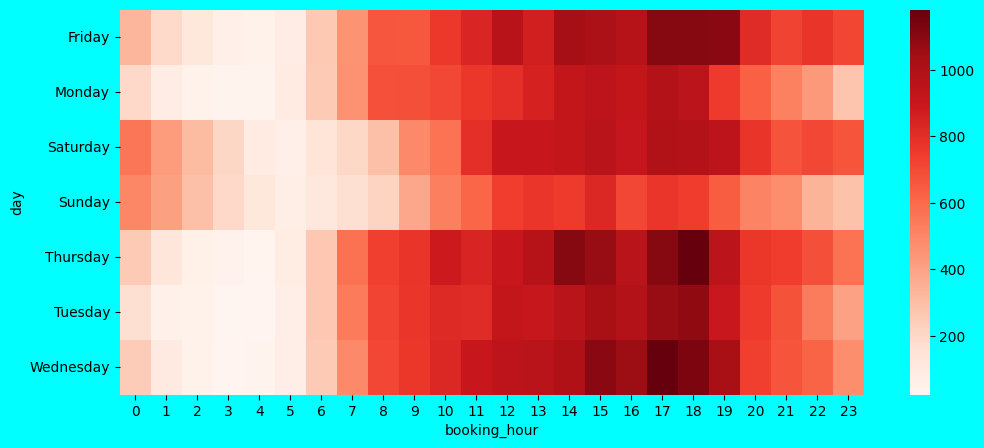

In [42]:
plt.figure(figsize=(12,5),facecolor= 'cyan')
sns.heatmap(pivot_heat,cmap='Reds')

#Here it is clear that  we can see there was some demand in saturday and sunday around 00:00 hours . suggesting that can be because of weekend late night parties,we can
#also see that around  6 - 7  the no of  trips are less in saturday and sunday copared to weekdays  .it can be because of  no scheduled works and people tend to
#relax ..hence less demand.As we have have analysed previosly that  from  6 'o' clock generally the demand tend to gradually rise and  goes to the peak at 18:00 hours
#and then gradually decreases.

In [43]:
#df.to_parquet('Nyc_taxi_dataset_sample(100_000 rows)')

In [44]:
import geopandas as gpd

#NYC Taxi Pickup Demand by Zone

In [45]:
gdf =  gpd.read_file('https://github.com/rahuldattaroy2727-cmd/Nyc-Taxi-Trips--Bigquery-Pandas-Maplotlib-analysis/raw/refs/heads/main/nyc_taxi_trips/taxi_zones_shape_file/taxi_zones.shp')

In [46]:
gdf['LocationID']=gdf['LocationID'].astype(int)
df['pickup_location_id']=df['pickup_location_id'].astype(int)
df['dropoff_location_id']=df['dropoff_location_id'].astype(int)

In [47]:
red=df.groupby(df['pickup_location_id']).size()

In [48]:
red.name='pickup_count'

In [49]:
pickup_map=gdf.merge(red,left_on='LocationID',right_index=True,how='left')

(np.float64(905464.7390389859),
 np.float64(1075092.878374982),
 np.float64(112485.76061678902),
 np.float64(280480.4146430247))

<Figure size 1200x1200 with 0 Axes>

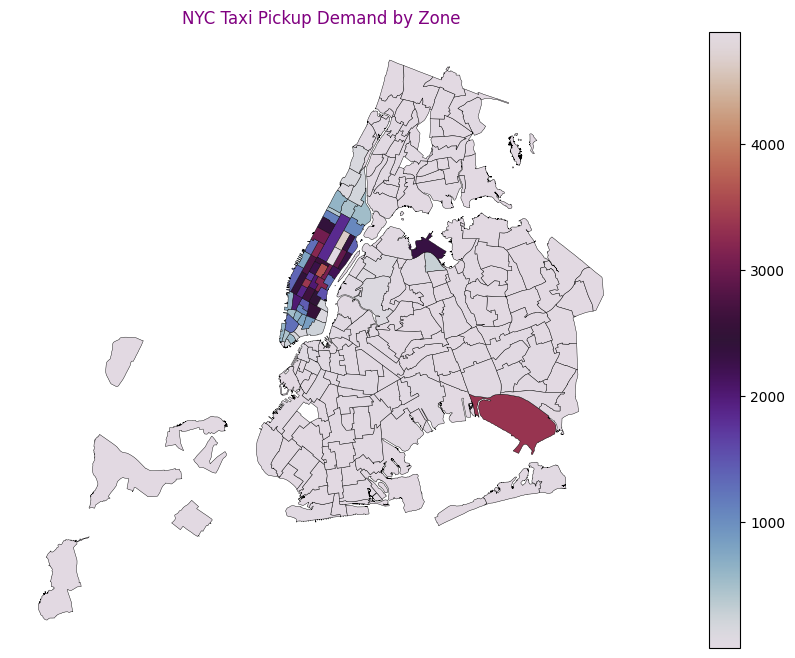

In [50]:
plt.figure(figsize=(12,12))
pickup_map.plot(column='pickup_count' ,cmap='twilight', legend=True, figsize=(20, 8), edgecolor='black', linewidth=0.3)



plt.title('NYC Taxi Pickup Demand by Zone',color='purple')
plt.axis('off')

#NYC Taxi Dropoff by zone

In [51]:
blue=df.groupby(df['dropoff_location_id']).size()

In [52]:
blue.name='dropoff_count'

In [53]:
dropoff_map= gdf.merge(blue,left_on='LocationID',right_index=True,how='inner')

Text(0.5, 1.0, 'NYC Taxi Dropoff by zone')

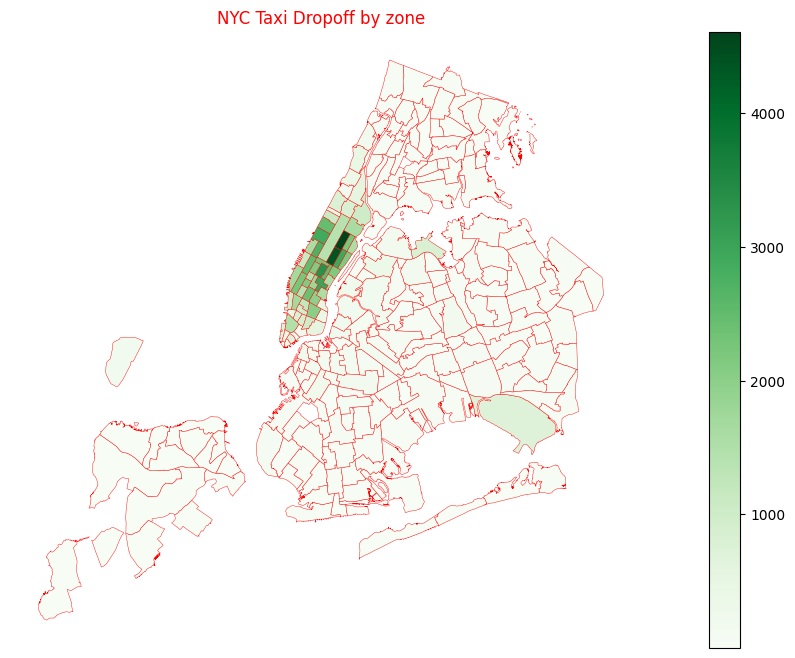

In [54]:
dropoff_map.plot(column='dropoff_count',cmap='Greens',legend=True,figsize=(20,8),edgecolor='Red',linewidth=0.3)
plt.axis('off')
plt.title('NYC Taxi Dropoff by zone',color='Red')

#Average fare by zone map

In [55]:
green =df.groupby(df['pickup_location_id'])['fare_amount'].mean()

In [56]:
green.name='Average_fare_by_zone'

In [57]:
fare_map = gdf.merge(green,left_on='LocationID',right_index=True,how='inner')

Text(0.5, 1.0, 'Average fare by zone map')

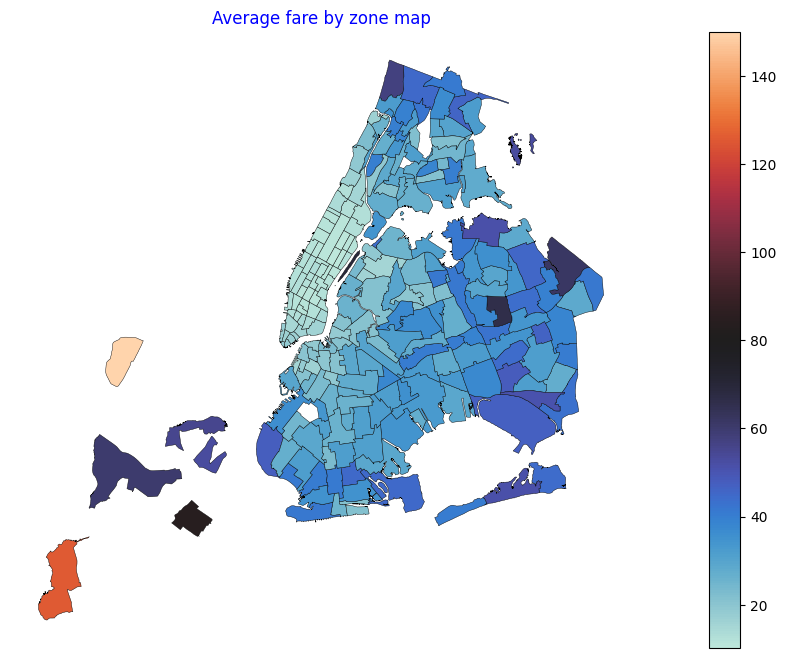

In [58]:
fare_map.plot(column='Average_fare_by_zone',cmap='icefire',linewidth=0.3,figsize=(20,8),legend=True,edgecolor='Black')
plt.axis('off')
plt.title('Average fare by zone map',color='Blue')